_____________
# Importing packages

In [1]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from config import *
from collections import Counter
from pathlib import Path
from scipy.stats import spearmanr
from scipy.stats import ttest_ind, levene
from bertopic import BERTopic
from gensim.models.coherencemodel import CoherenceModel
from gensim.corpora import Dictionary

# Loading data

In [2]:
# Docs
with open(FINAL_DOCS_PATH, "rb") as f:
    docs_bert = pickle.load(f)

# Merged topics
merged_topics_df = pd.read_excel(MERGED_TOPICS_CATEGORIES_PATH)

# Merged model & topics
merged_topics = np.load(MERGED_TOPICS_PATH)

In [3]:
print(f"Nr. of topics: {len(merged_topics_df)}")

Nr. of topics: 477


# Topic Coherence Score

Below, we extract the top words for each topic from `merged_topics` across all documents.

In [4]:
# Calculate topic words from merged_topics
unique_topics = np.unique(merged_topics)
topic_words = []
topic_ids = []

# Prepare documents
tokenized_docs = [doc.lower().split() for doc in docs_bert]
dictionary = Dictionary(tokenized_docs)

for topic_id in unique_topics:
    if topic_id == -1:  # Skip outliers
        continue
    
    # Get ALL documents for this topic from merged_topics instead of 50,000
    doc_indices = np.where(merged_topics == topic_id)[0]
    topic_docs = [docs_bert[i] for i in doc_indices]
    
    # Extract top words
    all_words = []
    for doc in topic_docs:
        all_words.extend(doc.lower().split())
    
    word_counts = Counter(all_words)
    top_words = [word for word, _ in word_counts.most_common(10)]
    
    topic_words.append(top_words)
    topic_ids.append(topic_id)

print(f"Topic words count: {len(topic_words)}")
print(f"Unique topics in merged_topics (excl. -1): {len([t for t in unique_topics if t != -1])}")

# Verify they match
assert len(topic_words) == len([t for t in unique_topics if t != -1]), "Mismatch!"

Topic words count: 476
Unique topics in merged_topics (excl. -1): 476


To calculate the overall coherence score we are using `gensim.models.CoherenceModel`.

In [5]:
# Calculate average coherence for all 476 topics (including duplicates from outlier & main model)
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v',
    processes=4  # Use multiple cores
)

coherence_score = coherence_model.get_coherence()
print(f"\n📊 Topic Coherence (C_v): {coherence_score:.4f}")


📊 Topic Coherence (C_v): 0.7197


In [6]:
# Get median and STD coherence per topic
coherence_per_topic = coherence_model.get_coherence_per_topic()
print(f"Median coherence: {np.median(coherence_per_topic):.4f}")
print(f"Std deviation: {np.std(coherence_per_topic):.4f}")

Median coherence: 0.7758
Std deviation: 0.2239


## Visualize topic coherence scores

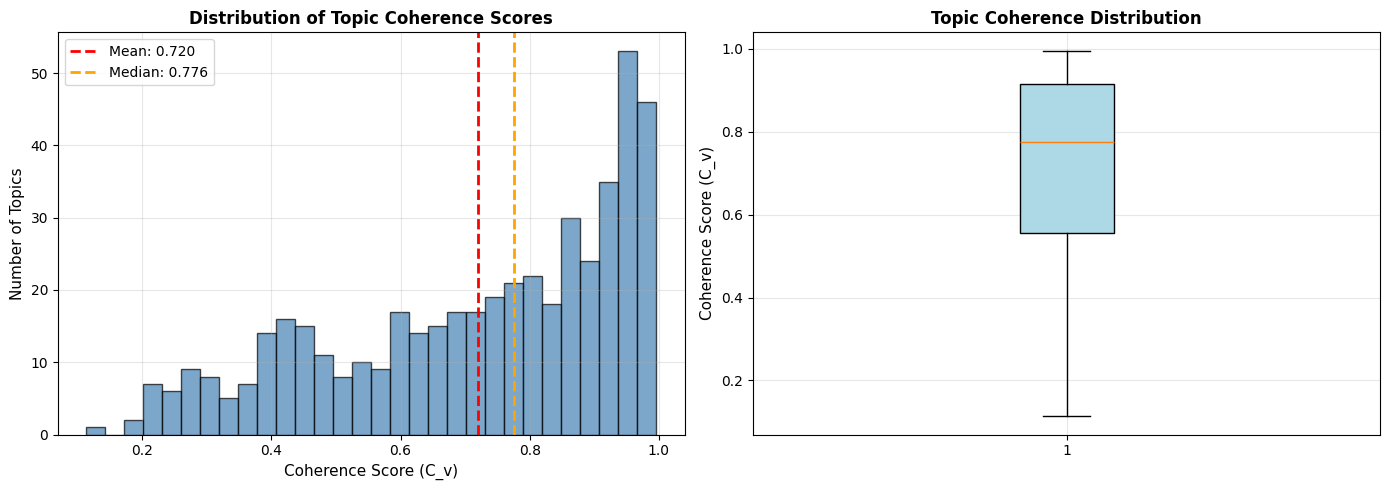

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of coherence scores
axes[0].hist(coherence_per_topic, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].axvline(np.mean(coherence_per_topic), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {np.mean(coherence_per_topic):.3f}')
axes[0].axvline(np.median(coherence_per_topic), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {np.median(coherence_per_topic):.3f}')
axes[0].set_xlabel('Coherence Score (C_v)', fontsize=11)
axes[0].set_ylabel('Number of Topics', fontsize=11)
axes[0].set_title('Distribution of Topic Coherence Scores', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot
box = axes[1].boxplot(coherence_per_topic, patch_artist=True)
box['boxes'][0].set_facecolor('lightblue')
axes[1].set_ylabel('Coherence Score (C_v)', fontsize=11)
axes[1].set_title('Topic Coherence Distribution', fontsize=12, fontweight='bold')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


## Best and worst topics

Below we create a DataFrame with all topics (merging duplicates below based on manual labeling) including their coherence score.

In [8]:
# Count documents per topic
topic_counts = Counter(merged_topics)

# Filter merged_topic_info_with_category to include only the topics in topic_ids
topic_info_filtered = merged_topics_df[
    merged_topics_df['Topic ID'].isin(topic_ids)
].set_index('Topic ID')

topic_coherence_df = pd.DataFrame({
    'Topic ID': topic_ids,
    'Coherence': coherence_per_topic,   # from your previous coherence calculation
    'Top Words': [' '.join(words[:5]) for words in topic_words],  # top 5 words
    'Document Count': [topic_counts[tid] for tid in topic_ids],        # doc counts
    'Topic Label': topic_info_filtered['Topic Label'].reindex(topic_ids).values,
    'Category': topic_info_filtered['Category'].reindex(topic_ids).values,
    'Source Model': topic_info_filtered['Source Model'].reindex(topic_ids).values
})

# Sort by coherence
topic_coherence_df = topic_coherence_df.sort_values('Coherence', ascending=False)

In [9]:
topic_coherence_df.head(3)

,Topic ID,Coherence,Top Words,Document Count,Topic Label,Category,Source Model
376,376,0.995912,theamazingdigitalcircus tadc digitalcircus pom...,2171,The Amazing Digital Circus,Media franchises,Outlier Model
363,363,0.995594,miraculous miraculousladybug ladybug chatnoir mlb,2538,Miraculous Ladybug,Media franchises,Outlier Model
434,434,0.994786,heartstopper nicknelson kitconnor charliesprin...,2201,Heartstopper,Media franchises,Outlier Model


In [10]:
# Consolidate topics by Topic Label - combining duplicates
topic_coherence_df_merged = topic_coherence_df.groupby('Topic Label').agg({
    'Topic ID': lambda x: ', '.join(map(str, x)),        # List all topic IDs in this label
    'Coherence': 'mean',                                 # Average coherence
    'Document Count': 'sum',                              # Total documents
    'Top Words': 'first',                                # Take first set of words
    'Category': 'first',                                 # Assume same category
    'Source Model': lambda x: ', '.join(x.unique())      # Show which models contributed
}).reset_index()

print(f"Number of merged topic labels: {len(topic_coherence_df_merged)}")

Number of merged topic labels: 305


In [11]:
topic_coherence_df_merged.head(5)

,Topic Label,Topic ID,Coherence,Document Count,Top Words,Category,Source Model
0,2024 US election,224,0.503193,2521,usa trump politics america biden,Politics and social issues,Main Model
1,3D printing,400,0.868032,1590,3dprinting 3dprinted 3d diy printer,Hobbies,Outlier Model
2,ASMR,243,0.875471,9739,asmr satisfying asmrsounds asmrvideo oddlysati...,Emotional and reflective content,Outlier Model
3,Acting,86,0.669332,7949,acting pov actor story actress,TikTok video types,Main Model
4,Advice,278,0.386029,4008,tips advice tipsandtricks tipsforgirls marketi...,Advice,Outlier Model


In [12]:
# Save topic coherence df (merged, 304 topics + 1 incoherent)
topic_coherence_df_merged.to_excel(TOPIC_COHERENCE_PATH, index=False)

In [13]:
# Sort by coherence
topic_coherence_df = topic_coherence_df.sort_values('Coherence', ascending=False)

# Show top topics
print("\n🏆 TOP 5 MOST COHERENT:")
print("=" * 120)
for idx, row in topic_coherence_df.head(5).iterrows():
    label = row['Topic Label']
    coherence = row['Coherence']
    size = int(row['Document Count'])
    topic_ids = row['Topic ID']
    sources = row['Source Model']
    words = row['Top Words']
    category = row['Category']
    
    print(f"Label: {label:>5} | Coherence: {coherence:.3f} | Document count: {size:>1,} | Category: {category:>1}")
    print(f"           Topic IDs: {topic_ids} | Sources: {sources}")
    print(f"           \nTop words: {words}")
    print("-"*100)


🏆 TOP 5 MOST COHERENT:
Label: The Amazing Digital Circus | Coherence: 0.996 | Document count: 2,171 | Category: Media franchises
           Topic IDs: 376 | Sources: Outlier Model
           
Top words: theamazingdigitalcircus tadc digitalcircus pomni jax
----------------------------------------------------------------------------------------------------
Label: Miraculous Ladybug | Coherence: 0.996 | Document count: 2,538 | Category: Media franchises
           Topic IDs: 363 | Sources: Outlier Model
           
Top words: miraculous miraculousladybug ladybug chatnoir mlb
----------------------------------------------------------------------------------------------------
Label: Heartstopper | Coherence: 0.995 | Document count: 2,201 | Category: Media franchises
           Topic IDs: 434 | Sources: Outlier Model
           
Top words: heartstopper nicknelson kitconnor charliespring heartstopperseason2
-------------------------------------------------------------------------------------

In [14]:
# Show bottom topics
print("\n🚫 TOP 5 LEAST COHERENT:")
print("=" * 120)
for idx, row in topic_coherence_df.tail(5).iterrows():
    label = row['Topic Label']
    coherence = row['Coherence']
    size = int(row['Document Count'])
    topic_ids = row['Topic ID']
    sources = row['Source Model']
    words = row['Top Words']
    category = row['Category']
    
    print(f"Label: {label:>5} | Coherence: {coherence:.3f} | Document count: {size:>1,} | Category: {category:>1}")
    print(f"           Topic IDs: {topic_ids} | Sources: {sources}")
    print(f"           \nTop words: {words}")
    print("-"*100)


🚫 TOP 5 LEAST COHERENT:
Label: Incoherent | Coherence: 0.208 | Document count: 1,501 | Category: Incoherent
           Topic IDs: 418 | Sources: Outlier Model
           
Top words: mrbeast mrbeastchallenge npcsthoughts mrnobodyisreal mrbeast6000
----------------------------------------------------------------------------------------------------
Label: Incoherent | Coherence: 0.206 | Document count: 3,167 | Category: Incoherent
           Topic IDs: 356 | Sources: Outlier Model
           
Top words: quotes explore swavyquotes thoughtzzzz__ thoughtzzzz__quotes
----------------------------------------------------------------------------------------------------
Label: Tom Holland & Zendaya | Coherence: 0.196 | Document count: 8,482 | Category: Celebrities/influencers
           Topic IDs: 133 | Sources: Main Model
           
Top words: tomholland interview tomhollandstories pov bridgerton
--------------------------------------------------------------------------------------------------

## Incoherent topics

What is the coherence score for topics we manually labelled as "incoherent"? Are they scoring lower on this metric than topics that were included?

In [15]:
# Filter for topics labeled as 'Incoherent'
incoherent_labeled_topics = topic_coherence_df[
    topic_coherence_df['Topic Label'].str.contains('Incoherent', case=False, na=False)
]

# Check if any exist
if len(incoherent_labeled_topics) > 0:
    print("\nSUMMARY STATISTICS FOR 'INCOHERENT' TOPICS")
    print("=" * 80)
    print(f"Number of topics       : {len(incoherent_labeled_topics)}")
    print(f"Mean coherence         : {incoherent_labeled_topics['Coherence'].mean():.3f}")
    print(f"Median coherence       : {incoherent_labeled_topics['Coherence'].median():.3f}")
    print(f"Std deviation          : {incoherent_labeled_topics['Coherence'].std():.3f}")
    print(f"Min coherence          : {incoherent_labeled_topics['Coherence'].min():.3f}")
    print(f"Max coherence          : {incoherent_labeled_topics['Coherence'].max():.3f}")
    print(f"Total documents        : {incoherent_labeled_topics['Document Count'].sum():,}")
    print(f"Mean topic size        : {incoherent_labeled_topics['Document Count'].mean():.0f}")
    print(f"Median topic size      : {incoherent_labeled_topics['Document Count'].median():.0f}")

    # Compare to overall average coherence
    overall_mean = topic_coherence_df['Coherence'].mean()
    incoherent_mean = incoherent_labeled_topics['Coherence'].mean()
    diff_pct = (incoherent_mean - overall_mean) / overall_mean * 100
    print(f"\nComparison to overall coherence:")
    print(f"  Overall mean coherence: {overall_mean:.3f}")
    print(f"  Mean incoherent topics: {incoherent_mean:.3f}")
    print(f"  Difference             : {diff_pct:.1f}%")

else:
    print("No topics found with 'Incoherent' label")


SUMMARY STATISTICS FOR 'INCOHERENT' TOPICS
Number of topics       : 95
Mean coherence         : 0.449
Median coherence       : 0.424
Std deviation          : 0.175
Min coherence          : 0.113
Max coherence          : 0.879
Total documents        : 603,440
Mean topic size        : 6352
Median topic size      : 2681

Comparison to overall coherence:
  Overall mean coherence: 0.720
  Mean incoherent topics: 0.449
  Difference             : -37.6%


### Visualize difference

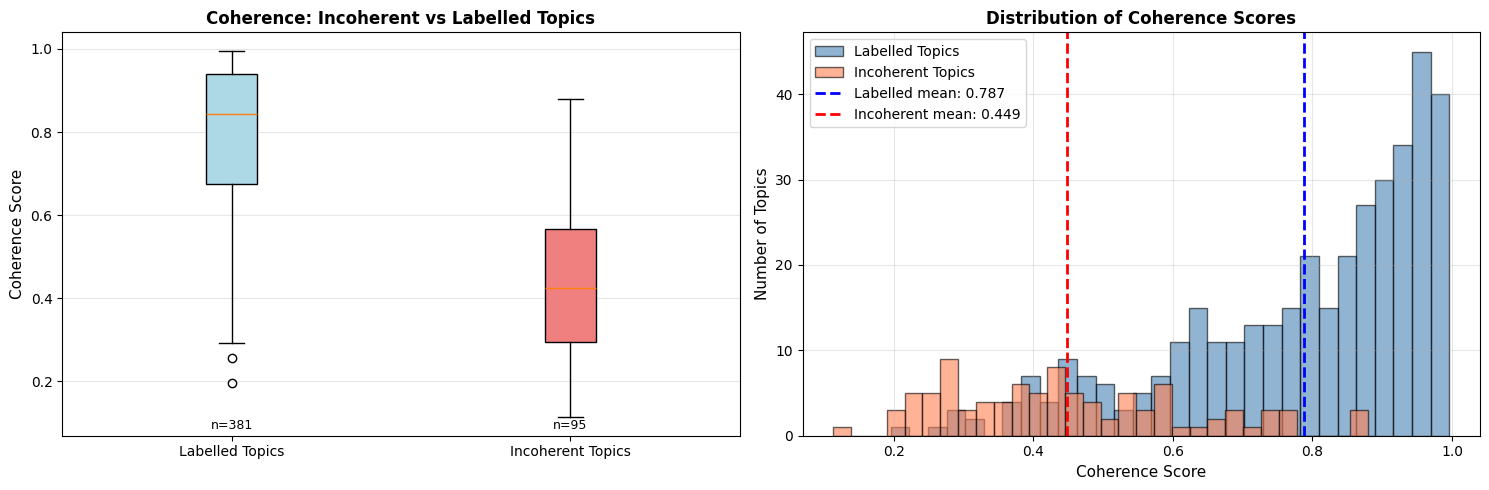


Independent samples t-test:
  t-statistic: 16.4920
  P-value: 0.000000
  ✓ Significant difference (p < 0.05)

  Levene's test for equal variances: p = 0.8741

Comparison Statistics:
----------------------------------------------------------------------
  Labelled Topics:
    Mean: 0.7872
    Median: 0.8434
    Std: 0.1798
    Count: 381

  Incoherent Topics:
    Mean: 0.4489
    Median: 0.4240
    Std: 0.1753
    Count: 95

  Difference:
    Mean difference: 0.3383
    Effect size (Cohen's d): 1.906 (large)


In [16]:
# Create comparison
topic_coherence_df['Is_Incoherent'] = topic_coherence_df['Topic Label'].str.contains(
    'Incoherent', case=False, na=False
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Box plot comparison
coherent_scores = topic_coherence_df[~topic_coherence_df['Is_Incoherent']]['Coherence']
incoherent_scores = topic_coherence_df[topic_coherence_df['Is_Incoherent']]['Coherence']

bp = axes[0].boxplot(
    [coherent_scores, incoherent_scores],
    tick_labels=['Labelled Topics', 'Incoherent Topics'],
    patch_artist=True
)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][1].set_facecolor('lightcoral')

axes[0].set_ylabel('Coherence Score', fontsize=11)
axes[0].set_title('Coherence: Incoherent vs Labelled Topics', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# Add sample sizes
axes[0].text(1, axes[0].get_ylim()[0] + 0.01, f'n={len(coherent_scores)}', 
             ha='center', va='bottom', fontsize=9)
axes[0].text(2, axes[0].get_ylim()[0] + 0.01, f'n={len(incoherent_scores)}', 
             ha='center', va='bottom', fontsize=9)

# Histogram comparison
axes[1].hist(coherent_scores, bins=30, alpha=0.6, label='Labelled Topics', 
             color='steelblue', edgecolor='black')
axes[1].hist(incoherent_scores, bins=30, alpha=0.6, label='Incoherent Topics', 
             color='coral', edgecolor='black')
axes[1].axvline(coherent_scores.mean(), color='blue', linestyle='--', linewidth=2,
                label=f'Labelled mean: {coherent_scores.mean():.3f}')
axes[1].axvline(incoherent_scores.mean(), color='red', linestyle='--', linewidth=2,
                label=f'Incoherent mean: {incoherent_scores.mean():.3f}')
axes[1].set_xlabel('Coherence Score', fontsize=11)
axes[1].set_ylabel('Number of Topics', fontsize=11)
axes[1].set_title('Distribution of Coherence Scores', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Save figure
fig.savefig(COHERENCE_FIGURE_PATH, dpi=300, bbox_inches='tight')
plt.show()

# Check for equal variances
stat_levene, p_levene = levene(coherent_scores, incoherent_scores)

# Statistical test - Independent samples t-test
if p_levene > 0.05:
    # Equal variances - use standard t-test
    t_statistic, pvalue = ttest_ind(coherent_scores, incoherent_scores)
    test_type = "Independent samples t-test"
else:
    # Unequal variances - use Welch's t-test
    t_statistic, pvalue = ttest_ind(coherent_scores, incoherent_scores, equal_var=False)
    test_type = "Welch's t-test (unequal variances)"

print(f"\n{test_type}:")
print(f"  t-statistic: {t_statistic:.4f}")
print(f"  P-value: {pvalue:.6f}")
if pvalue < 0.05:
    print(f"  ✓ Significant difference (p < 0.05)")
else:
    print(f"  ✗ No significant difference (p >= 0.05)")

print(f"\n  Levene's test for equal variances: p = {p_levene:.4f}")

# Additional statistics
print(f"\nComparison Statistics:")
print("-" * 70)
print(f"  Labelled Topics:")
print(f"    Mean: {coherent_scores.mean():.4f}")
print(f"    Median: {coherent_scores.median():.4f}")
print(f"    Std: {coherent_scores.std():.4f}")
print(f"    Count: {len(coherent_scores)}")

print(f"\n  Incoherent Topics:")
print(f"    Mean: {incoherent_scores.mean():.4f}")
print(f"    Median: {incoherent_scores.median():.4f}")
print(f"    Std: {incoherent_scores.std():.4f}")
print(f"    Count: {len(incoherent_scores)}")

print(f"\n  Difference:")
print(f"    Mean difference: {coherent_scores.mean() - incoherent_scores.mean():.4f}")

# Calculate Cohen's d (effect size)
pooled_std = np.sqrt((coherent_scores.std()**2 + incoherent_scores.std()**2) / 2)
cohens_d = (coherent_scores.mean() - incoherent_scores.mean()) / pooled_std
print(f"    Effect size (Cohen's d): {cohens_d:.3f}", end="")

# Interpret effect size
if abs(cohens_d) < 0.2:
    effect = "negligible"
elif abs(cohens_d) < 0.5:
    effect = "small"
elif abs(cohens_d) < 0.8:
    effect = "medium"
else:
    effect = "large"
print(f" ({effect})")

# Topic diversity

Additional check of topic diversity score.

The diversity score is calculated as the ratio of the number of unique words to the total number of words. A score close to 0 indicates that many topics share the same words (low diversity), while a score close to 1 means there is minimal overlap between topics (high diversity), reflecting a more varied and distinct set of topics.

In [17]:
# Calculate topic diversity
def calculate_topic_diversity(topic_words):
    # Flatten all topic words
    all_words = [word for topic in topic_words for word in topic]
    unique_words = set(all_words)
    
    diversity = len(unique_words) / len(all_words)
    return diversity

In [18]:
diversity_score = calculate_topic_diversity(topic_words)
print(f"\n📊 Topic Diversity: {diversity_score:.4f}") # Higher is better, 0 = all topics have same words, 1 = no word overlap


📊 Topic Diversity: 0.6723


________________
# AI disclosure statement

AI tools were used to assist:
- developing, labelling, and debugging code
- formatting Markdown cells

AI tools used:
- [CursorAI (Desktop version)](https://cursor.com/agents)
- [ClaudeAI](https://claude.ai/)
- [ChatGPT](https://chatgpt.com/)

I acknowledge my responsibility as a researcher to thoroughly verify all outputs and content produced by AI tools and accept full accountability for their accuracy and validity.

Inga Vondenhof